# Load in BIG_DATA2.csv

In [19]:
import csv
import pandas as pd  
import requests
# TODO FIX URL
url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/BIG_DATA2.csv"
df = pd.read_csv(url, index_col=0)

# Ziyue: Display the Visual

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [21]:
# --- 2. Identify Top 5 Genres Overall ---
# Calculate the overall top 5 most frequent genres
genre_counts = df['genre'].value_counts()
top_5_genres = genre_counts.head(5).index.tolist()

print("\nOverall Top 5 Genres:")
print(genre_counts.head(5).to_markdown())


Overall Top 5 Genres:
| genre       |   count |
|:------------|--------:|
| Pop         |  106412 |
| Rock        |   47227 |
| R&B         |   40511 |
| Rap/Hip Hop |   35221 |
| Country     |   32739 |


In [22]:
# --- 3. Data Preparation for Time Series ---
# A. Convert 'date' to datetime and extract year
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# B. Filter data for the requested years (1958 to 2021)
df_filtered = df[(df['year'] >= 1958) & (df['year'] <= 2021)].copy()

# C. Filter to include only the top 5 genres
df_top5 = df_filtered[df_filtered['genre'].isin(top_5_genres)]

# D. Group by year and genre to get the count of chart appearances
genre_evolution = df_top5.groupby(['year', 'genre']).size().reset_index(name='count')

KeyError: 'date'

In [ ]:
# --- 4. Visualization ---
sns.set_theme(style='whitegrid')

plt.figure(figsize=(15, 7))

# Create the line plot
sns.lineplot(
    data=genre_evolution, 
    x='year', 
    y='count', 
    hue='genre', 
    linewidth=2.5, 
    palette='Spectral',
)

# Set English titles and labels
plt.title('Evolution of Top 5 Genres (1958-2021)', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Songs', fontsize=16)
plt.legend(title='Genre', title_fontsize='12', fontsize='10', loc='upper left')

# Set explicit X-axis limits and ticks for clarity
plt.xlim(1958, 2021)

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.7)

# Save the chart
output_image_name = 'top_5_genres_visualization.png'
plt.savefig(output_image_name, dpi=300, bbox_inches='tight')
plt.show()

# Namisha: 

# Rachel: Display the Correlation Analysis

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Load in pre-processed file

In [27]:
import csv
import pandas as pd  
import requests

url = "https://raw.githubusercontent.com/joseph15809/ECE143_Music_Genre_Prediction/refs/heads/main/data/genre_proportions_by_Y_top_5BIG_DATA2.csv"
df = pd.read_csv(url, index_col=0)

In [28]:
#csv_path = "genre_proportions_by_Y_top_5_BIG_DATA2.csv"
#df = pd.read_csv(csv_path, index_col=0)
corr = df.corr()
corr

,Pop,Rock,R&B,Rap/Hip Hop,Country
Pop,1.000000,0.816063,0.264102,-0.890936,-0.740971
Rock,0.816063,1.000000,0.358507,-0.890715,-0.775491
R&B,0.264102,0.358507,1.000000,-0.508859,-0.467643
Rap/Hip Hop,-0.890936,-0.890715,-0.508859,1.000000,0.679174
Country,-0.740971,-0.775491,-0.467643,0.679174,1.000000


Generate a Clustered Heatmap of genre correlations:

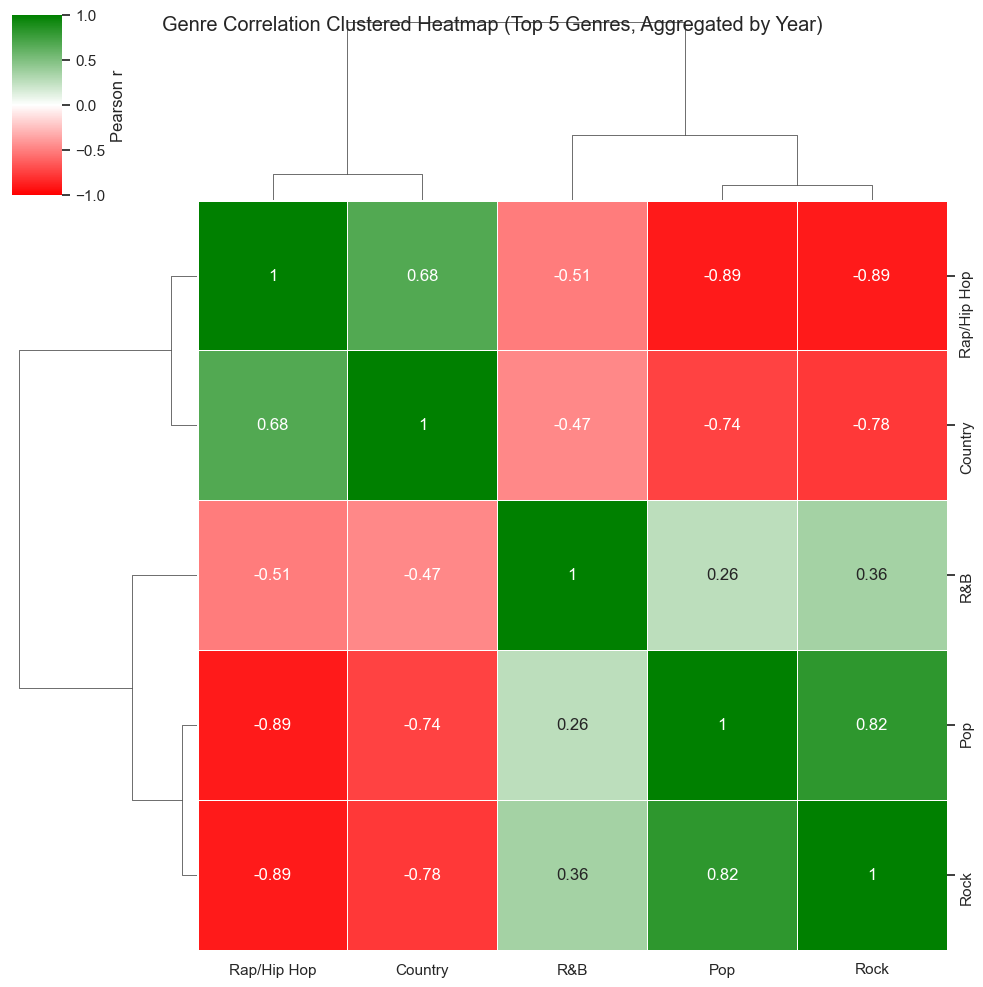

In [29]:
# 7. Visualization: Clustered Heatmap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_corr", ["red","white","green"]) # custom colormap, red -1 white +0 green +1

sns.set_theme(context='notebook', style='white') # Set visual theme as notebook

cluster = sns.clustermap(data=corr, 
                         figsize=(10,10), 
                         metric='euclidean', 
                         method='average',
                         annot=True,
                         cmap=cmap,
                         vmin=-1, vmax=1,center=0, # ensure symmetry
                         cbar_kws={'label': 'Pearson r'},
                         linewidths=0.5
                        )
plt.suptitle('Genre Correlation Clustered Heatmap (Top 5 Genres, Aggregated by Year)')
plt.show()